In [15]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score

In [18]:
# Helper Function to Clean Demographic Names
def clean_feature_name(name):
    if name.startswith("occupation_"):
        occ = name.replace("occupation_", "")
        if occ == "none":
            occ = "unemployed/none"
        return f"{occ.capitalize()} (Occupation)"
    elif name.startswith("gender_"):
        gender_char = name.replace("gender_", "")
        gender_name = "Male" if gender_char == "M" else "Female"
        return f"{gender_name} (Gender)"
    elif name == "age":
        return "Older Age"
    return name

## Extend use case from recommendations result for clustering

In [2]:
## Utilize schema from readme
u_data_cols = ['user_id', 'item_id', 'rating', 'timestamp']
u_item_cols = ['item_id', 'movie_title', 'release_date', 'video_release_date', 'IMDb_URL', 'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
u_user_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']

In [3]:
df_users = pd.read_csv('data/u.user', sep='|', names=u_user_cols, encoding='latin-1')
df_items = pd.read_csv('data/u.item', sep='|', names=u_item_cols, encoding='latin-1')
df_ratings_base = pd.read_csv('data/ua.base', sep='\t', names=u_data_cols, encoding='latin-1')
df_ratings_test = pd.read_csv('data/ua.test', sep='\t', names=u_data_cols, encoding='latin-1')

In [4]:
df_users

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213
...,...,...,...,...,...
938,939,26,F,student,33319
939,940,32,M,administrator,02215
940,941,20,M,student,97229
941,942,48,F,librarian,78209


In [5]:
V=loaded = np.load("data/V_matrix.npy")

In [6]:
V.shape

(22, 1682)

In [7]:
df_users

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213
...,...,...,...,...,...
938,939,26,F,student,33319
939,940,32,M,administrator,02215
940,941,20,M,student,97229
941,942,48,F,librarian,78209


In [16]:
# =========================================================
# STEP 1: Reconstruct the correct 22 One-Hot Encoded Column Names
# =========================================================
df_temp = df_users[["user_id", "age", "gender", "occupation"]].copy()
df_temp = pd.get_dummies(
    df_temp, columns=["gender", "occupation"], drop_first=True
)
demographic_features = df_temp.drop(columns=["user_id"]).columns.tolist()

V_movie_demographics = V.T

In [17]:
# =========================================================
# STEP 2: Grid Search to Find Optimal k (Composite Selection)
# =========================================================
print("=============================================")
print("         RUNNING K-MEANS GRID SEARCH         ")
print("=============================================")

k_range = range(2, 9)  # Exploring k from 2 to 8
grid_results = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(V_movie_demographics)

    # Calculate metrics for evaluation
    sil = silhouette_score(V_movie_demographics, labels_temp)
    db = davies_bouldin_score(V_movie_demographics, labels_temp)
    inertia = kmeans_temp.inertia_

    # Store raw values
    grid_results.append(
        {"k": k, "inertia": inertia, "silhouette": sil, "davies_bouldin": db}
    )
    print(
        f"Candidate k = {k} | Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f} | Inertia: {inertia:.1f}"
    )

# Convert results to a DataFrame for easy ranking
df_grid = pd.DataFrame(grid_results)

# Rank Silhouette (Descending: Higher is better, Rank 1 is best)
df_grid["sil_rank"] = df_grid["silhouette"].rank(ascending=False)

# Rank Davies-Bouldin (Ascending: Lower is better, Rank 1 is best)
df_grid["db_rank"] = df_grid["davies_bouldin"].rank(ascending=True)

# Calculate Combined Rank (Lower is better)
df_grid["composite_rank"] = df_grid["sil_rank"] + df_grid["db_rank"]

# Sort by composite rank (lowest rank wins).
# If there's a tie, the candidate with the higher Silhouette score wins.
df_grid_sorted = df_grid.sort_values(by=["composite_rank", "sil_rank"])

# Extract the winning k
best_k = int(df_grid_sorted.iloc[0]["k"])
best_sil = df_grid_sorted.iloc[0]["silhouette"]
best_db = df_grid_sorted.iloc[0]["davies_bouldin"]

# Print the ranking table so you can verify the math
print("\n--- GRID SEARCH RANKING TABLE ---")
columns_to_show = [
    "k",
    "silhouette",
    "sil_rank",
    "davies_bouldin",
    "db_rank",
    "composite_rank",
]
print(df_grid_sorted[columns_to_show].to_string(index=False))

print(f"\n=> Grid Search complete.")
print(f"=> Optimal k Selected: {best_k}")
print(f"   • Silhouette Score: {best_sil:.4f} (Rank {df_grid_sorted.iloc[0]['sil_rank']:.0f})")
print(f"   • Davies-Bouldin  : {best_db:.4f} (Rank {df_grid_sorted.iloc[0]['db_rank']:.0f})\n")

         RUNNING K-MEANS GRID SEARCH         
Candidate k = 2 | Silhouette: 0.1486 | Davies-Bouldin: 3.1545 | Inertia: 3364.6
Candidate k = 3 | Silhouette: 0.1413 | Davies-Bouldin: 2.9104 | Inertia: 3225.5
Candidate k = 4 | Silhouette: 0.1315 | Davies-Bouldin: 2.9237 | Inertia: 3121.8
Candidate k = 5 | Silhouette: 0.1231 | Davies-Bouldin: 2.9137 | Inertia: 3044.8
Candidate k = 6 | Silhouette: 0.1192 | Davies-Bouldin: 2.9976 | Inertia: 2980.0
Candidate k = 7 | Silhouette: 0.1192 | Davies-Bouldin: 2.9122 | Inertia: 2932.6
Candidate k = 8 | Silhouette: 0.1208 | Davies-Bouldin: 2.9613 | Inertia: 2889.1

--- GRID SEARCH RANKING TABLE ---
 k  silhouette  sil_rank  davies_bouldin  db_rank  composite_rank
 3    0.141343       2.0        2.910438      1.0             3.0
 4    0.131531       3.0        2.923737      4.0             7.0
 5    0.123090       4.0        2.913659      3.0             7.0
 2    0.148623       1.0        3.154503      7.0             8.0
 7    0.119245       6.0     

In [19]:
# =========================================================
# STEP 3: Fit Final Model on the Optimal k
# =========================================================
best_k = 3
num_clusters = best_k
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
movie_clusters = kmeans.fit_predict(V_movie_demographics)

# Calculate final metrics
final_sil_score = silhouette_score(V_movie_demographics, movie_clusters)
final_db_index = davies_bouldin_score(V_movie_demographics, movie_clusters)
final_inertia = kmeans.inertia_

df_movie_analysis = df_items.copy()
df_movie_analysis["cluster"] = movie_clusters

title_col = df_items.columns[1]

# =========================================================
# STEP 4: Print Demographic Profiles of the Best Clusters
# =========================================================
print("=============================================")
print(f"    FINAL DEMOGRAPHIC SEGMENTATION (k={num_clusters})     ")
print("=============================================\n")

print("--- FINAL CLUSTERING QUALITY METRICS ---")
print(f"• Inertia (Compactness)           : {final_inertia:.2f}")
print(f"• Silhouette Score (Separation)   : {final_sil_score:.3f}")
print(f"• Davies-Bouldin Index            : {final_db_index:.3f}")
print("----------------------------------------\n")

for i in range(num_clusters):
    cluster_movies = df_movie_analysis[df_movie_analysis["cluster"] == i]
    cluster_size = len(cluster_movies)

    movie_indices = cluster_movies.index.tolist()
    weights_in_cluster = V_movie_demographics[movie_indices, :]

    mean_weights = weights_in_cluster.mean(axis=0)
    feature_weights = pd.Series(mean_weights, index=demographic_features)

    # Find top 3 demographics
    appeals_to = feature_weights.sort_values(ascending=False).head(3)
    appeals_to_list = [
        f"{clean_feature_name(feat)} ({weight:.2f})"
        for feat, weight in appeals_to.items()
    ]

    # Find top 3 demographics (lowest/most negative weights)
    disliked_by = feature_weights.sort_values(ascending=True).head(3)
    disliked_by_list = []
    for feat, weight in disliked_by.items():
        cleaned_name = clean_feature_name(feat)
        if feat == "age":
            cleaned_name = "Younger Age (Appeals to)"
            disliked_by_list.append(f"{cleaned_name} ({abs(weight):.2f})")
        else:
            disliked_by_list.append(f"{cleaned_name} ({weight:.2f})")

    samples = cluster_movies[title_col].head(5).tolist()

    print(f"MOVIE CLUSTER {i} ({cluster_size} movies):")
    print(f"  • Highly Appeals To  : {', '.join(appeals_to_list)}")
    print(f"  • Disliked/Avoided By: {', '.join(disliked_by_list)}")
    print(f"  • Sample Movies      : {', '.join(samples)}")
    print("-" * 55)

    FINAL DEMOGRAPHIC SEGMENTATION (k=3)     

--- FINAL CLUSTERING QUALITY METRICS ---
• Inertia (Compactness)           : 3225.47
• Silhouette Score (Separation)   : 0.141
• Davies-Bouldin Index            : 2.910
----------------------------------------

MOVIE CLUSTER 0 (921 movies):
  • Highly Appeals To  : Unemployed/none (Occupation) (0.08), Executive (Occupation) (0.03), Lawyer (Occupation) (0.03)
  • Disliked/Avoided By: Younger Age (Appeals to) (0.07), Librarian (Occupation) (-0.05), Writer (Occupation) (-0.05)
  • Sample Movies      : Four Rooms (1995), Get Shorty (1995), Twelve Monkeys (1995), Seven (Se7en) (1995), Usual Suspects, The (1995)
-------------------------------------------------------
MOVIE CLUSTER 1 (493 movies):
  • Highly Appeals To  : Older Age (0.21), Student (Occupation) (0.14), Lawyer (Occupation) (0.10)
  • Disliked/Avoided By: Healthcare (Occupation) (-0.79), Writer (Occupation) (-0.08), Retired (Occupation) (-0.07)
  • Sample Movies      : Toy Story (19

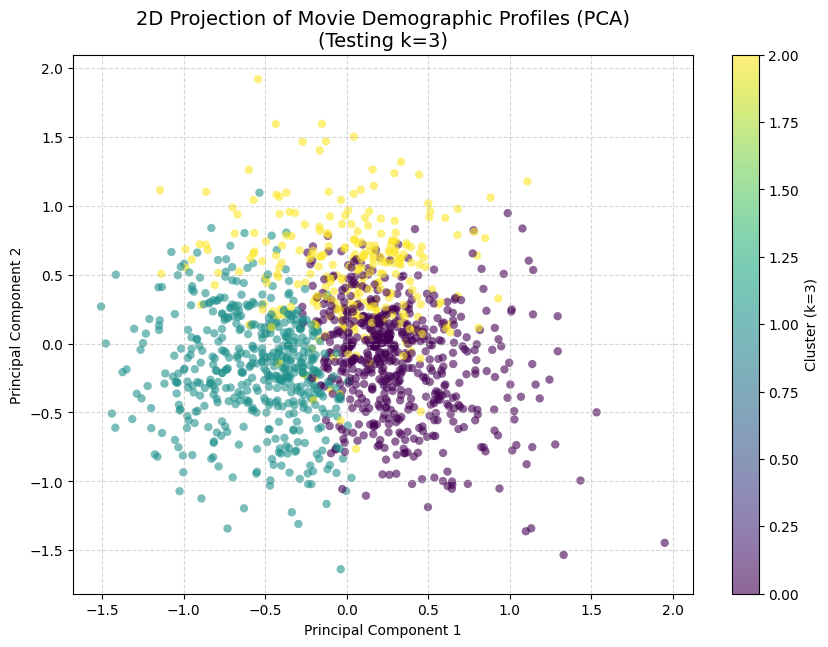

In [20]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Project the 22D movie vectors down to 2D
pca = PCA(n_components=2, random_state=42)
V_2d = pca.fit_transform(V_movie_demographics)

# 2. Get cluster labels for k=3 (which DB Index favored)
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(V_movie_demographics)

# 3. Plot the data
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    V_2d[:, 0],
    V_2d[:, 1],
    c=labels_3,
    cmap="viridis",
    alpha=0.6,
    edgecolors="none",
)
plt.colorbar(scatter, label="Cluster (k=3)")
plt.title(
    "2D Projection of Movie Demographic Profiles (PCA)\n(Testing k=3)",
    fontsize=14,
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()